In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import h5py
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, HMC
from numpyro.infer.util import initialize_model
from numpyro import handlers

jax.config.update("jax_enable_x64", True)

sys.path.append('../')

from bridge.forward_model.config import Constants, FMConfig
from bridge.forward_model.fmodel import FModel
from bridge.forward_model.fourier import my_ifft
from bridge.forward_model.bias import manage_params
from bridge.forward_model.plot_utils import stats_plot_for_article_2

20


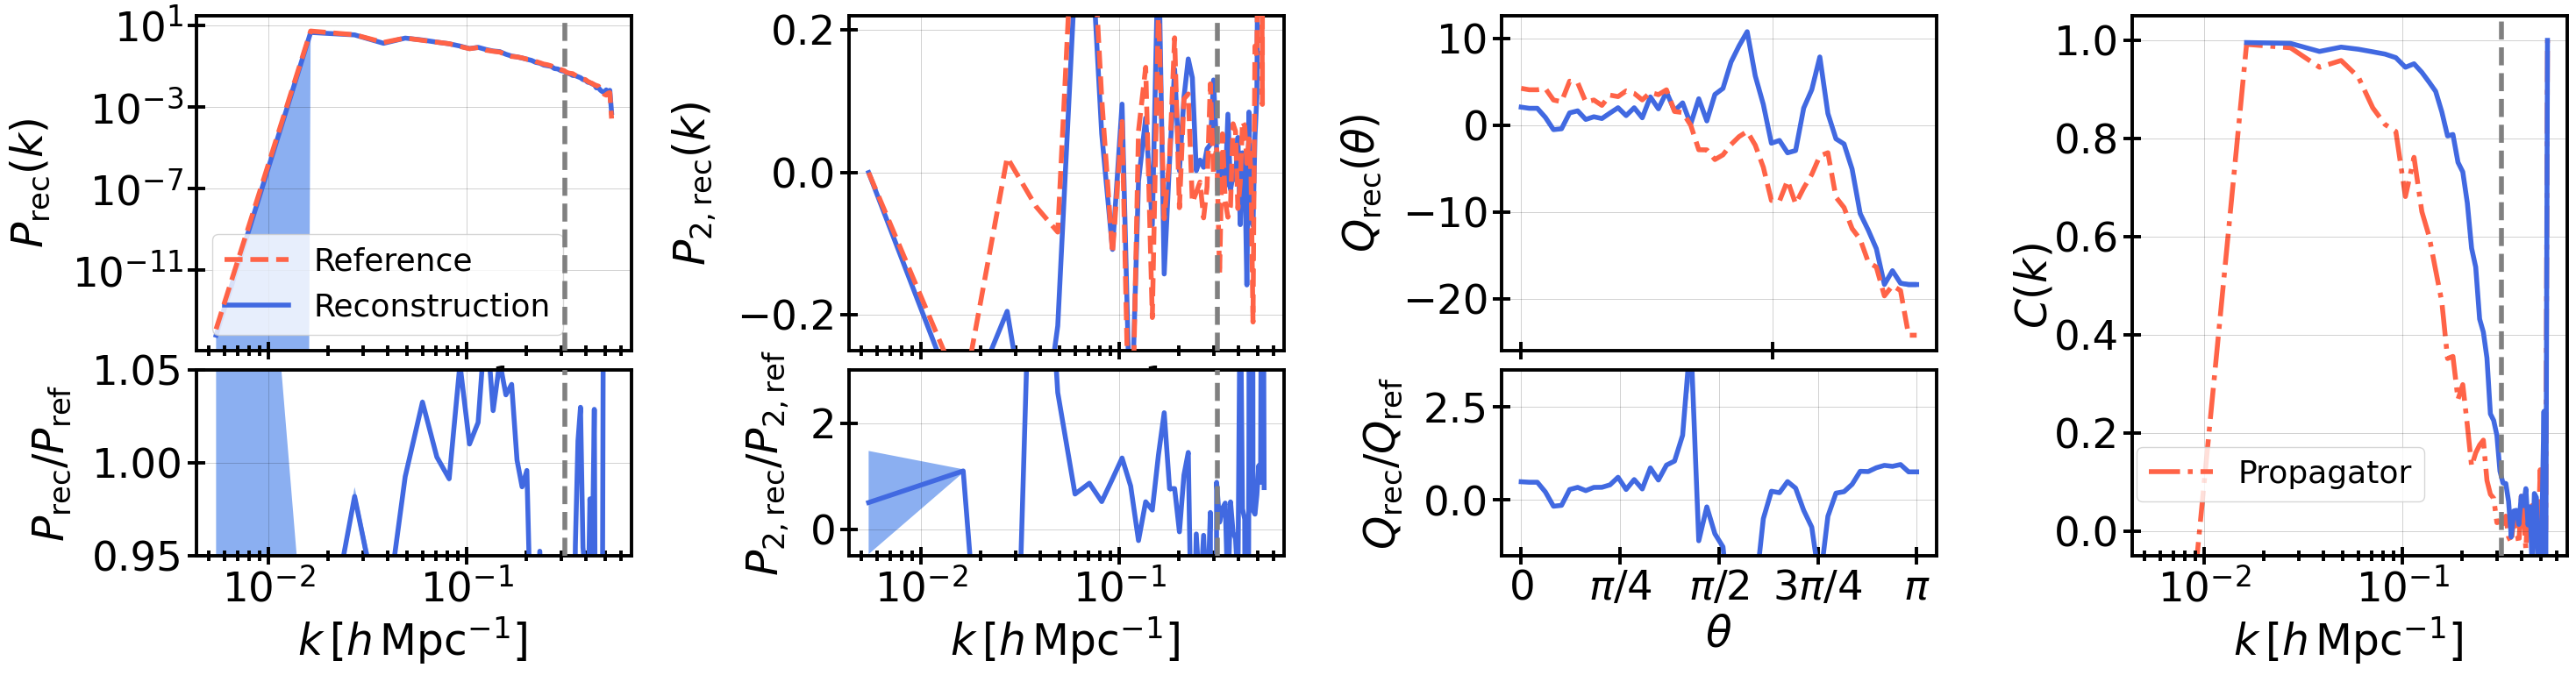

In [ ]:
fig, axs = stats_plot_for_article_2(bk_rat_y_lim = (-1.5, 1.5))

lw = 0.5 * 8
color_ref = 'tomato'#"k"
ls_ref = "--"
zorder_ref = 10

color_rec_mean = 'royalblue'#'r'
color_rec = 'cornflowerblue'#"lightcoral"
ls_rec = "-"
zorder_rec = 1

ref_label = r"Reference"
rec_label = r"Reconstruction"
extra_label = r"Propagator"

alpha_fill = 0.75


N = 32
R = 10

datapath = f"results/N{N}_R{R}_S02.hdf5"
with h5py.File(datapath, "r") as h5_file:

    header = h5_file['Header']
    M1 = header.attrs['N_paths']
    print(M1)

    k_c = np.array(h5_file['k_c'][:])
    thetas = np.array(h5_file['thetas'][:])

    din_ref_pk = np.array(h5_file["din_ref_pk"][:])
    din_pks = np.array(h5_file["din_pks"][:])
    din_pk_rats = np.array(h5_file["din_pk_rats"][:])

    din_ref_q = np.array(h5_file["din_ref_quad"][:])
    din_qs = np.array(h5_file["din_quad"][:])
    din_q_rats = np.array(h5_file["din_quad_rats"][:])

    ntr_ref_pk = np.array(h5_file["ntr_ref_pk"][:])
    ntr_pks = np.array(h5_file["ntr_pks"][:])
    ntr_pk_rats = np.array(h5_file["ntr_pk_rats"][:])

    din_ref_bispec = np.array(h5_file["din_ref_bispec"][:])
    din_bispecs = np.array(h5_file["din_bispecs"][:])
    din_bispec_rats = np.array(h5_file["din_bispec_rats"][:])

    ntr_ref_bispec = np.array(h5_file["ntr_ref_bispec"][:])
    ntr_bispecs = np.array(h5_file["ntr_bispecs"][:])
    ntr_bispec_rats = np.array(h5_file["ntr_bispec_rats"][:])

    din_crosses = np.array(h5_file["din_crosses"][:])
    ntr_crosses = np.array(h5_file["ntr_crosses"][:])

    propagator = np.array(h5_file["propagator"][:])



M_bi = 0

# Power spectra
din_pks_bi = din_pks[:, :M_bi]
din_pks = din_pks[:, M_bi:]

din_pk_rats_bi = din_pk_rats[:, :M_bi]
din_pk_rats = din_pk_rats[:, M_bi:]

ntr_pks_bi = ntr_pks[:, :M_bi]
ntr_pks = ntr_pks[:, M_bi:]

ntr_pk_rats_bi = ntr_pk_rats[:, :M_bi]
ntr_pk_rats = ntr_pk_rats[:, M_bi:]


# quad
din_qs_bi = din_qs[:, :M_bi]
din_qs = din_qs[:, M_bi:]

din_q_rats_bi = din_q_rats[:, :M_bi]
din_q_rats = din_q_rats[:, M_bi:]




# Bispectra

din_bispecs_bi = din_bispecs[:, :M_bi]
din_bispecs = din_bispecs[:, M_bi:]

din_bispec_rats_bi = din_bispec_rats[:, :M_bi]
din_bispec_rats = din_bispec_rats[:, M_bi:]

ntr_bispecs_bi = ntr_bispecs[:, :M_bi]
ntr_bispecs = ntr_bispecs[:, M_bi:]

ntr_bispec_rats_bi = ntr_bispec_rats[:, :M_bi]
ntr_bispec_rats = ntr_bispec_rats[:, M_bi:]

# Cross spectra
din_crosses_bi = din_crosses[:, :M_bi]
din_crosses = din_crosses[:, M_bi:]

ntr_crosses_bi = ntr_crosses[:, :M_bi]
ntr_crosses = ntr_crosses[:, M_bi:]



## PK
# din
din_pks_mean = din_pks.mean(axis=1)
din_pks_std = din_pks.std(axis=1)

din_pk_rats_mean = din_pk_rats.mean(axis=1)
din_pk_rats_std = din_pk_rats.std(axis=1)

# ntr
ntr_pks_mean = ntr_pks.mean(axis=1)
ntr_pks_std = ntr_pks.std(axis=1)

ntr_pk_rats_mean = ntr_pk_rats.mean(axis=1)
ntr_pk_rats_std = ntr_pk_rats.std(axis=1)

## QUAD
din_qs_mean = din_qs.mean(axis=1)
din_qs_std = din_qs.std(axis=1)

din_q_rats_mean = din_q_rats.mean(axis=1)
din_q_rats_std = din_q_rats.std(axis=1)

# BISPEC
# din
din_bispecs_mean = din_bispecs.mean(axis=1)
din_bispecs_std = din_bispecs.std(axis=1)

din_bispec_rats_mean = din_bispec_rats.mean(axis=1)
din_bispec_rats_std = din_bispec_rats.std(axis=1)

# n_tr
ntr_bispecs_mean = ntr_bispecs.mean(axis=1)
ntr_bispecs_std = ntr_bispecs.std(axis=1)

ntr_bispec_rats_mean = ntr_bispec_rats.mean(axis=1)
ntr_bispec_rats_std = ntr_bispec_rats.std(axis=1)


# CROSS
din_crosses_mean = din_crosses.mean(axis=1)
din_crosses_std = din_crosses.std(axis=1)

ntr_crosses_mean = ntr_crosses.mean(axis=1)
ntr_crosses_std = ntr_crosses.std(axis=1)



axs[0].plot(k_c, din_ref_pk, c=color_ref, ls=ls_ref, lw=lw, zorder=zorder_ref, label=ref_label)
axs[0].plot(k_c, din_pks_mean, c=color_rec_mean, ls=ls_rec, lw=lw, zorder=zorder_rec+1, label=rec_label)
axs[0].fill_between(
    k_c,
    din_pks_mean - din_pks_std,
    din_pks_mean + din_pks_std,
    facecolor=color_rec,
    ls=ls_rec,
    lw=0.0,
    zorder=zorder_rec,
    alpha=alpha_fill
)

axs[3].plot(k_c, din_pk_rats_mean, c=color_rec_mean, ls=ls_rec, lw=lw, zorder=zorder_rec+1)
axs[3].fill_between(
    k_c,
    din_pk_rats_mean - din_pk_rats_std,
    din_pk_rats_mean + din_pk_rats_std,
    facecolor=color_rec,
    ls=ls_rec,
    lw=0.0,
    zorder=zorder_rec,
    alpha=alpha_fill
)



axs[1].plot(k_c, din_ref_q, c=color_ref, ls=ls_ref, lw=lw, zorder=zorder_ref, label=ref_label)
axs[1].plot(k_c, din_qs_mean, c=color_rec_mean, ls=ls_rec, lw=lw, zorder=zorder_rec+1, label=rec_label)
axs[1].fill_between(
    k_c,
    din_qs_mean - din_qs_std,
    din_qs_mean + din_qs_std,
    facecolor=color_rec,
    ls=ls_rec,
    lw=0.0,
    zorder=zorder_rec,
    alpha=alpha_fill
)


axs[4].plot(k_c, din_q_rats_mean, c=color_rec_mean, ls=ls_rec, lw=lw, zorder=zorder_rec+1)
axs[4].fill_between(
    k_c,
    din_q_rats_mean - din_q_rats_std,
    din_q_rats_mean + din_q_rats_std,
    facecolor=color_rec,
    ls=ls_rec,
    lw=0.0,
    zorder=zorder_rec,
    alpha=alpha_fill
)



axs[2].plot(thetas, din_ref_bispec, c=color_ref, ls=ls_ref, lw=lw, zorder=zorder_ref)
axs[2].plot(thetas, din_bispecs_mean, c=color_rec_mean, ls=ls_rec, lw=lw, zorder=zorder_rec+1)
axs[2].fill_between(
    thetas,
    din_bispecs_mean - din_bispecs_std,
    din_bispecs_mean + din_bispecs_std,
    facecolor=color_rec,
    ls=ls_rec,
    lw=0.0,
    zorder=zorder_rec,
    alpha=alpha_fill,
)

axs[5].plot(thetas, din_bispec_rats_mean, c=color_rec_mean, ls=ls_rec, lw=lw, zorder=zorder_rec+1)
axs[5].fill_between(
    thetas,
    din_bispec_rats_mean - din_bispec_rats_std,
    din_bispec_rats_mean + din_bispec_rats_std,
    facecolor=color_rec,
    ls=ls_rec,
    lw=0.0,
    zorder=zorder_rec,
    alpha=alpha_fill
)

axs[6].plot(k_c, propagator, c=color_ref, ls='-.', lw=lw, zorder=zorder_rec, label=extra_label)
axs[6].plot(k_c, din_crosses_mean, c=color_rec_mean, ls=ls_rec, lw=lw, zorder=zorder_rec+1)
axs[6].fill_between(
    k_c,
    din_crosses_mean - din_crosses_std,
    din_crosses_mean + din_crosses_std,
    facecolor=color_rec,
    ls=ls_rec,
    lw=0.0,
    zorder=zorder_rec,
    alpha=alpha_fill,
)



fact_legend = 6.5
axs[0].legend(fontsize=lw*fact_legend, loc='lower left')
axs[6].legend(fontsize=lw*fact_legend, loc=(0.01, 0.1))

# axs[0].set_ylim(9e-4, 5)
# axs[1].set_ylim(0.7, 2.1)
# axs[5].set_ylim(-1.5, 1.5)
# axs[3].set_ylim(0.90, 1.1)


axs[1].set_ylim(-0.25, 0.22)

axs[3].set_ylim(0.95, 1.05)
axs[4].set_ylim(-0.5, 3)
axs[5].set_ylim(-1.5, 3.5)

L = N*R
k_nyq = np.pi / (L/N)
for ax in [axs[0], axs[1], axs[3], axs[4], axs[6]]:
    ax.axvline(k_nyq, ls='dashed', color='grey', zorder=101, lw=lw*1)



# figpath = os.path.join(this_file_dir, 'figures', f'din_stats_N{N}_R{R:0.0f}_2.png')
# fig.savefig(figpath, bbox_inches='tight')

# figpath = os.path.join(this_file_dir, 'figures', f'din_stats_N{N}_R{R:0.0f}_2.pdf')
# fig.savefig(figpath, bbox_inches='tight')
